In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics import Accuracy, Precision, Recall

In [2]:
# Load datasets
from torchvision import datasets, models
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # ResNet expects 224x224
    transforms.Grayscale(num_output_channels=3),  # convert 1 → 3 channels
    transforms.ToTensor()
])


In [3]:
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

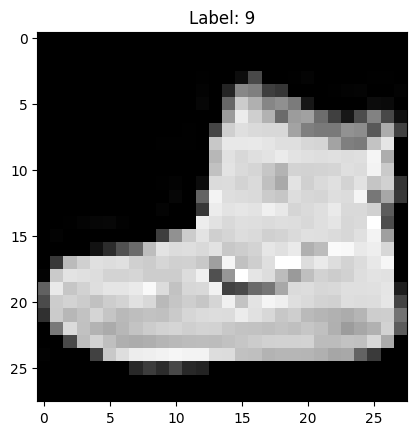

In [4]:
import matplotlib.pyplot as plt

# get one sample
image, label = train_data[0]

# FashionMNIST images are 1x28x28 → remove channel dimension
image = image.squeeze()

plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [5]:
model = models.resnet18(pretrained=True)


/Users/apple/PycharmProjects/cloth-image-classifier/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/apple/PycharmProjects/cloth-image-classifier/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

In [7]:
num_classes = 10  # FashionMNIST

model.fc = nn.Linear(model.fc.in_features, num_classes)

In [8]:
for param in model.parameters():
    param.requires_grad = False

# unfreeze last layer
for param in model.fc.parameters():
    param.requires_grad = True

In [9]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [10]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

In [11]:
def train(model, loader, epochs=5):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in loader:
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader)}")

In [12]:
train(model, train_loader, epochs=5)

Epoch 1, Loss: 1.2180928806304931
Epoch 2, Loss: 1.107485672346751
Epoch 3, Loss: 1.094837216091156
Epoch 4, Loss: 1.0813605500062307
Epoch 5, Loss: 1.080330470720927


In [13]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", correct / total)

Accuracy: 0.6375
